# Claim-conditioned classifier judge sweep

**Classifier head** with A's (and optionally B's) asserted digit shown to
the judge as additional input. Trained with **multiclass cross-entropy**
on the true class label $y$ -- *not* with BCE on "is $d_A$ correct".

The motivation is the failure mode demonstrated in
`binary_verifier_sweep.ipynb`: BCE on the selected play has no
within-input discrimination signal and collapses to a constant
marginal-rate prediction. Multiclass CE ranks all 10 classes against
each other per training step, so the discrimination signal is present.

**Architecture.**

* **CNN backbone**: $C$, $2C$, or $4C$ input channels (consultancy /
  debate / control). With $c_2 = 32$ and `img_size = 18` it produces a
  $32 \times 4 \times 4 = 512$-dim feature vector $f$.
* **MLP head**: takes
  - $(f, \text{onehot}(d_A))$ for `n_query_digits = 1` -- head input dim
    $= 522$. Used by consultancy and asymmetric debate.
  - $(f, \text{onehot}(d_A), \text{onehot}(d_B))$ for `n_query_digits = 2`
    -- head input dim $= 532$. Used by symmetric and last-$d_B$ debate.
  Output: **10 logits**. Softmax + CE on the true label.

**Selection score.** For each (path, $d_A$) [or (path, $d_A$, $d_B$)]
the score used by A's minmax is
$\;p(\cdot, d_A) = \mathrm{softmax}(\text{head}(\cdot, d_A, [d_B]))_{d_A}$ --
the judge's posterior probability of $d_A$ given the reveal and the
asserted digits. The reduction trees are identical to the binary
notebook.

**Training step.** After the minmax pick of $(a^*, b^*, d_A^*, [d_B^*])$
we do one full forward on the selected play with $d_A = d_A^*$
(and $d_B = d_B^*$ for 2q), get 10 logits, and apply CE against the
true $y$.

Each judge saves weights (`.pt`), step losses, per-epoch selection
accuracy, per-epoch judge accuracy, per-epoch belief, and the
loss / metric plots.


In [1]:
import os, gc, time, itertools
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CONFIG = {
    # ----- dataset -----
    'dataset':            'fashionmnist_normalized',   # mnist | mnist_normalized | fashionmnist | ... | cifar10
    # ----- image / mask geometry -----
    'img_size':           18,
    'grid_size':          6,
    'squares_to_keep':    4,
    # ----- training (shared) -----
    'batch_size':         128,
    'epochs':             10,
    'lr':                 1e-3,
    'lr_decay':           0.85,
    # ----- forward chunk sizes -----
    # cnn_chunk : how many paths through CNN at once
    # head_chunk_1q / head_chunk_2q : how many paths through the MLP head at once
    #   (smaller for n_query_digits=2 because each path expands by 100 combos)
    'cnn_chunk':          16000,
    'head_chunk_1q':      4096,
    'head_chunk_2q':      512,
    'eval_amp':           True,
    # ----- judge MLP head -----
    'mlp_hidden':         64,
    # ----- consultancy specifics -----
    'consultancy_masks_per_image': 1296,
    # ----- 2-turn debate specifics (N_A * N_B = 1296 paths) -----
    'two_turn_N_A':       36,
    'two_turn_N_B':       36,
    # ----- 4-turn debate specifics (6^4 = 1296 paths) -----
    'four_turn_N_a1':     6,
    'four_turn_N_b1':     6,
    'four_turn_N_a2':     6,
    'four_turn_N_b2':     6,
    # ----- evaluation -----
    'eval_batch':         32,
    # ----- which scoring rules to run -----
    'scoring_rules':      ('asym', 'sym', 'lastdig'),
    # ----- IO -----
    'data_root':          './data',
    'plot_dir':           '/kaggle/working/claim_conditioned_plots',
    'data_dir':           '/kaggle/working/claim_conditioned_data',
    'weights_dir':        '/kaggle/working/claim_conditioned_weights',
    'device':             'cuda' if torch.cuda.is_available() else 'cpu',
}
NUM_CLASSES = 10

for d in (CONFIG['plot_dir'], CONFIG['data_dir'], CONFIG['weights_dir']):
    os.makedirs(d, exist_ok=True)

print(f"device: {CONFIG['device']}")
if CONFIG['device'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"free mem: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")
print(f"dataset: {CONFIG['dataset']}")
print(f"  consultancy: 1 x {CONFIG['consultancy_masks_per_image']} masks/img")
print(f"  2-turn:      N_A={CONFIG['two_turn_N_A']}, N_B={CONFIG['two_turn_N_B']} "
      f"-> {CONFIG['two_turn_N_A']*CONFIG['two_turn_N_B']} paths/img")
print(f"  4-turn:      ({CONFIG['four_turn_N_a1']}, {CONFIG['four_turn_N_b1']}, "
      f"{CONFIG['four_turn_N_a2']}, {CONFIG['four_turn_N_b2']}) "
      f"-> {CONFIG['four_turn_N_a1']*CONFIG['four_turn_N_b1']*CONFIG['four_turn_N_a2']*CONFIG['four_turn_N_b2']} paths/img")
print(f"  scoring_rules: {CONFIG['scoring_rules']}")


device: cuda
GPU: Tesla T4 | free mem: 15.53 GB
dataset: fashionmnist_normalized
  consultancy: 1 x 1296 masks/img
  2-turn:      N_A=36, N_B=36 -> 1296 paths/img
  4-turn:      (6, 6, 6, 6) -> 1296 paths/img
  scoring_rules: ('asym', 'sym', 'lastdig')


In [2]:
# Self-contained dataset loader (same as the multiclass notebook).

DATASET_REGISTRY = {
    'mnist':        (torchvision.datasets.MNIST,        1),
    'fashionmnist': (torchvision.datasets.FashionMNIST, 1),
    'cifar10':      (torchvision.datasets.CIFAR10,      3),
}


def _parse_tag(tag):
    if tag.endswith('_normalized'):
        return tag[:-len('_normalized')], True
    return tag, False


def _materialize(ds, img_size, channels):
    n = len(ds)
    X = torch.empty(n, channels, img_size, img_size, dtype=torch.float32)
    y = torch.empty(n, dtype=torch.long)
    resize = transforms.Resize((img_size, img_size), antialias=True)
    to_tensor = transforms.ToTensor()
    for i in range(n):
        img, lbl = ds[i]
        X[i] = to_tensor(resize(img))
        y[i] = lbl
    return X, y


def preprocess_dataset(tag, config=CONFIG):
    base, normalized = _parse_tag(tag)
    cls, channels = DATASET_REGISTRY[base]
    img_size = config['img_size']
    print(f"  loading {base} (normalize_per_class={normalized})...")
    train_raw = cls(root=config['data_root'], train=True,  download=True)
    test_raw  = cls(root=config['data_root'], train=False, download=True)
    Xtr, ytr = _materialize(train_raw, img_size, channels)
    Xte, yte = _materialize(test_raw,  img_size, channels)

    mean = Xtr.mean(dim=(0, 2, 3), keepdim=True)
    std  = Xtr.std(dim=(0, 2, 3),  keepdim=True).clamp_min(1e-6)
    Xtr = (Xtr - mean) / std
    Xte = (Xte - mean) / std

    if normalized:
        lam_shrink = 0.05
        D = channels * img_size * img_size
        X_all = torch.cat([Xtr, Xte], dim=0).view(-1, D).double()
        y_all = torch.cat([ytr, yte], dim=0)
        global_mean = X_all.mean(dim=0, keepdim=True)
        eye_D = torch.eye(D, dtype=X_all.dtype)
        mus, Ws = [], []
        for k in range(10):
            Xk = X_all[y_all == k]
            mu_k = Xk.mean(dim=0, keepdim=True)
            Xc = Xk - mu_k
            Sigma_k = (Xc.T @ Xc) / (Xc.size(0) - 1)
            trace_per_d = Sigma_k.diagonal().mean()
            Sigma_reg = Sigma_k + lam_shrink * trace_per_d * eye_D
            eigvals, U = torch.linalg.eigh(Sigma_reg)
            eigvals = eigvals.clamp_min(eigvals.max() * 1e-8)
            W_k = (U * eigvals.rsqrt().unsqueeze(0)) @ U.T
            mus.append(mu_k); Ws.append(W_k)
        def _apply(X, y):
            Xflat = X.view(X.size(0), D).double()
            out = torch.empty_like(Xflat)
            for k in range(10):
                m = (y == k)
                if m.any():
                    out[m] = (Xflat[m] - mus[k]) @ Ws[k] + global_mean
            return out.float().view(X.size(0), channels, img_size, img_size)
        Xtr = _apply(Xtr, ytr); Xte = _apply(Xte, yte)

    dev = config['device']
    return {
        'name':        tag,
        'normalized':  normalized,
        'X_train':     Xtr.to(dev),
        'y_train':     ytr.to(dev),
        'X_test':      Xte.to(dev),
        'y_test':      yte.to(dev),
        'in_channels': channels,
        'img_size':    img_size,
    }


print("Loading data ...")
DATA = preprocess_dataset(CONFIG['dataset'])
print(f"  X_train: {tuple(DATA['X_train'].shape)} | X_test: {tuple(DATA['X_test'].shape)}")


Loading data ...
  loading fashionmnist (normalize_per_class=True)...


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.0MB/s]


  X_train: (60000, 1, 18, 18) | X_test: (10000, 1, 18, 18)


In [3]:
# JudgeClassifier: CNN backbone + MLP head taking (features, onehot d_A,
# [onehot d_B]) -> NUM_CLASSES logits (softmax + CE training).
# `n_query_digits` is 1 (consultancy / asym) or 2 (sym / lastdig).

class JudgeClassifier(nn.Module):
    def __init__(self, in_channels, img_size=18, num_classes=10, widen=1,
                 n_query_digits=1, mlp_hidden=64, proj_dim=64):
        super().__init__()
        # CNN backbone is bit-identical to combined_judges_sweep.ipynb
        # (c1=c2=32*widen, feat_dim=512 with widen=1) so the multiclass
        # baseline comparisons stay valid. Speed comes from a learned
        # PROJECTION (Linear+ReLU) from feat_dim -> proj_dim that runs
        # ONCE per path, so the per-(d_A, d_B) head cost is tiny.
        c1, c2 = 32 * widen, 32 * widen
        self.features_net = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        feat_hw = img_size // 4
        cnn_feat_dim = c2 * feat_hw * feat_hw
        self.projection = nn.Sequential(
            nn.Linear(cnn_feat_dim, proj_dim),
            nn.ReLU(inplace=True),
        )
        self.feat_dim = proj_dim              # what downstream code sees from features_for
        self.num_classes = num_classes
        self.n_query_digits = n_query_digits
        head_in = self.feat_dim + n_query_digits * num_classes
        # Shrunk to a single hidden layer for speed (3x+ speedup on 2q
        # judges where each path expands into 100 digit combos through the head).
        self.head = nn.Sequential(
            nn.Linear(head_in, mlp_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(mlp_hidden, num_classes),
        )

    def features_for(self, x):
        # Returns PROJECTED features (proj_dim, not the raw 512-dim CNN
        # output). Projection cost amortized over all (d_A, d_B) combos.
        return self.projection(self.features_net(x).flatten(1))   # (B, proj_dim)

    def head_logits(self, feat, d_A, d_B=None):
        oh_A = F.one_hot(d_A, self.num_classes).float()
        if self.n_query_digits == 1:
            assert d_B is None, "n_query_digits=1 judge does not accept d_B"
            inp = torch.cat([feat, oh_A], dim=-1)
        else:
            assert d_B is not None, "n_query_digits=2 judge requires d_B"
            oh_B = F.one_hot(d_B, self.num_classes).float()
            inp = torch.cat([feat, oh_A, oh_B], dim=-1)
        return self.head(inp)                              # (B, num_classes)

    def forward(self, x, d_A, d_B=None):
        return self.head_logits(self.features_for(x), d_A, d_B)


def _widen_for(data):
    return 2 if data['in_channels'] == 3 else 1


def make_consultancy_judge(data):
    return JudgeClassifier(in_channels=data['in_channels'],
                       img_size=data['img_size'], widen=_widen_for(data),
                       num_classes=NUM_CLASSES, n_query_digits=1,
                       mlp_hidden=CONFIG['mlp_hidden']).to(CONFIG['device'])


def make_debate_judge(data, n_query_digits):
    return JudgeClassifier(in_channels=2 * data['in_channels'],
                       img_size=data['img_size'], widen=_widen_for(data),
                       num_classes=NUM_CLASSES, n_query_digits=n_query_digits,
                       mlp_hidden=CONFIG['mlp_hidden']).to(CONFIG['device'])


def make_control_judge(data, n_query_digits):
    return JudgeClassifier(in_channels=4 * data['in_channels'],
                       img_size=data['img_size'], widen=_widen_for(data),
                       num_classes=NUM_CLASSES, n_query_digits=n_query_digits,
                       mlp_hidden=CONFIG['mlp_hidden']).to(CONFIG['device'])


In [4]:
# Sampling helpers (same as combined_judges_sweep.ipynb).

def _amp_ctx(device, use_amp):
    if use_amp and device == 'cuda':
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def cells_to_pixel_mask(cells, grid_size, img_size):
    G = grid_size
    step = img_size // G
    shape = cells.shape[:-1]
    out = cells.reshape(*shape, 1, G, G)
    out = out.repeat_interleave(step, dim=-2).repeat_interleave(step, dim=-1)
    return out


def sample_consultancy_masks(B, M, grid_size, squares_to_keep, device):
    K = grid_size * grid_size
    rand = torch.rand(B, M, K, device=device)
    idx = rand.argsort(dim=2)[:, :, :squares_to_keep]
    out = torch.zeros(B, M, K, device=device)
    out.scatter_(2, idx, 1.0)
    return out


def sample_2turn_paths(B, N_A, N_B, grid_size, device):
    K = grid_size * grid_size
    rand_A = torch.rand(B, N_A, K, device=device)
    a_idx = rand_A.argsort(dim=2)[:, :, :2]
    a_cells = torch.zeros(B, N_A, K, device=device)
    a_cells.scatter_(2, a_idx, 1.0)

    avail = 1.0 - a_cells
    rand_B = torch.rand(B, N_A, N_B, K, device=device)
    rand_B = torch.where(avail.unsqueeze(2).bool(),
                          rand_B, torch.full_like(rand_B, -1.0))
    b_idx = rand_B.topk(2, dim=3, largest=True).indices
    b_cells = torch.zeros(B, N_A, N_B, K, device=device)
    b_cells.scatter_(3, b_idx, 1.0)
    return a_cells, b_cells, a_idx, b_idx


def sample_4turn_paths(B, N_a1, N_b1, N_a2, N_b2, grid_size, device):
    K = grid_size * grid_size

    def _pick_one(avail, rand):
        rand = torch.where(avail.bool(), rand, torch.full_like(rand, -1.0))
        return rand.argmax(dim=-1)

    ones_full = torch.ones(B, N_a1, K, device=device)
    a1_idx = _pick_one(ones_full, torch.rand(B, N_a1, K, device=device))
    a1_mask = torch.zeros(B, N_a1, K, device=device)
    a1_mask.scatter_(2, a1_idx.unsqueeze(2), 1.0)

    avail_b1 = (1.0 - a1_mask).unsqueeze(2).expand(B, N_a1, N_b1, K)
    rand_b1 = torch.rand(B, N_a1, N_b1, K, device=device)
    b1_idx = _pick_one(avail_b1, rand_b1)
    b1_mask = torch.zeros(B, N_a1, N_b1, K, device=device)
    b1_mask.scatter_(3, b1_idx.unsqueeze(3), 1.0)

    avail_a2 = (1.0 - a1_mask.unsqueeze(2) - b1_mask).clamp_min(0)
    avail_a2 = avail_a2.unsqueeze(3).expand(B, N_a1, N_b1, N_a2, K)
    rand_a2 = torch.rand(B, N_a1, N_b1, N_a2, K, device=device)
    a2_idx = _pick_one(avail_a2, rand_a2)
    a2_mask = torch.zeros(B, N_a1, N_b1, N_a2, K, device=device)
    a2_mask.scatter_(4, a2_idx.unsqueeze(4), 1.0)

    avail_b2 = (1.0 - a1_mask.unsqueeze(2).unsqueeze(3)
                     - b1_mask.unsqueeze(3)
                     - a2_mask).clamp_min(0)
    avail_b2 = avail_b2.unsqueeze(4).expand(B, N_a1, N_b1, N_a2, N_b2, K)
    rand_b2 = torch.rand(B, N_a1, N_b1, N_a2, N_b2, K, device=device)
    b2_idx = _pick_one(avail_b2, rand_b2)
    b2_mask = torch.zeros(B, N_a1, N_b1, N_a2, N_b2, K, device=device)
    b2_mask.scatter_(5, b2_idx.unsqueeze(5), 1.0)

    full_shape = (B, N_a1, N_b1, N_a2, N_b2, K)
    a1_full = a1_mask.view(B, N_a1, 1, 1, 1, K).expand(full_shape)
    a2_full = a2_mask.view(B, N_a1, N_b1, N_a2, 1, K).expand(full_shape)
    b1_full = b1_mask.view(B, N_a1, N_b1, 1, 1, K).expand(full_shape)
    A_total = (a1_full + a2_full).clamp_max(1).contiguous()
    B_total = (b1_full + b2_mask).clamp_max(1).contiguous()
    return A_total, B_total, a1_idx, b1_idx, a2_idx, b2_idx


In [5]:
# CORE TRICK: judge_probs_all_digits.
#
# For each (path, d_A) [, d_B] the judge returns NUM_CLASSES logits; we
# softmax and extract the [d_A] component -- the judge's posterior
# probability of d_A given the reveal and asserted digits. That is the
# score A's minmax tree operates on.
#
# Returns probs of shape:
#   n_query_digits == 1: (M, C)
#   n_query_digits == 2: (M, C, C)  [d_A, d_B]
#
# No grad here -- this is the selection/evaluation forward.

@torch.no_grad()
def judge_probs_all_digits(judge, paths, n_query_digits, cnn_chunk, head_chunk,
                           amp_ctx, num_classes=NUM_CLASSES):
    M = paths.size(0); C = num_classes; device = paths.device
    if n_query_digits == 1:
        probs = torch.empty(M, C, device=device)
    else:
        probs = torch.empty(M, C, C, device=device)
    eye_C = torch.eye(C, device=device)

    for cs in range(0, M, cnn_chunk):
        ce = min(cs + cnn_chunk, M)
        with amp_ctx:
            f_chunk = judge.features_for(paths[cs:ce]).float()    # (ch, D)
        D = f_chunk.size(1)
        ch = ce - cs
        for hs in range(0, ch, head_chunk):
            he = min(hs + head_chunk, ch)
            f = f_chunk[hs:he]                                   # (sub, D)
            sub = he - hs
            if n_query_digits == 1:
                # head input: (sub * C, D + C); output: (sub * C, C) logits.
                # After softmax: (sub, C, C) where [i, d_A, c] = P(c | path i, d_A).
                # Score we want: probs[i, d_A] = softmax[i, d_A, d_A].
                f_exp = f.unsqueeze(1).expand(-1, C, -1)         # (sub, C, D)
                oh_A  = eye_C.unsqueeze(0).expand(sub, C, C)     # (sub, C, C)
                inp   = torch.cat([f_exp, oh_A], dim=-1).reshape(sub * C, D + C)
                with amp_ctx:
                    logits = judge.head(inp).float()             # (sub*C, C)
                sm = torch.softmax(logits, dim=-1).view(sub, C, C)
                diag_idx = torch.arange(C, device=device).view(1, C, 1).expand(sub, C, 1)
                probs[cs + hs : cs + he] = sm.gather(2, diag_idx).squeeze(2)
            else:
                # head input: (sub*C*C, D+2C); output: (sub*C*C, C) logits.
                # softmax view: (sub, C_A, C_B, C). Score: softmax[i, d_A, d_B, d_A].
                f_exp = f.unsqueeze(1).unsqueeze(2).expand(-1, C, C, -1)
                oh_A  = eye_C.unsqueeze(0).unsqueeze(2).expand(sub, C, C, C)
                oh_B  = eye_C.unsqueeze(0).unsqueeze(1).expand(sub, C, C, C)
                inp   = torch.cat([f_exp, oh_A, oh_B], dim=-1).reshape(sub * C * C, D + 2 * C)
                with amp_ctx:
                    logits = judge.head(inp).float()             # (sub*C*C, C)
                sm = torch.softmax(logits, dim=-1).view(sub, C, C, C)
                diag_idx = torch.arange(C, device=device).view(1, C, 1, 1).expand(sub, C, C, 1)
                probs[cs + hs : cs + he] = sm.gather(3, diag_idx).squeeze(3)
            del inp, logits, sm
        del f_chunk
    return probs


In [6]:
# Reduce trees. Each takes probs (..., extra digit dims) and returns the
# selected indices + claim. For 1-query the extra-dim is (C,) for d_A;
# for 2-query the extra-dims are (C, C) for (d_A, d_B).

# ---- consultancy: argmax over (M, C) ----
def _consultancy_reduce(probs):
    """probs: (b, M, C). Returns (claim, m_star)."""
    b, M, C = probs.shape
    flat = probs.view(b, M * C)
    best = flat.argmax(dim=1)
    m_star = best // C
    claim = best %  C
    return claim, m_star


# ---- asym (1 query digit) ----
def _asym_2turn_reduce(probs):
    """probs: (b, N_A, N_B, C).
    max_{d_A} max_{a1} min_{b1} p[a1, b1, d_A]."""
    b, N_A, N_B, C = probs.shape
    V_b = probs.min(dim=2).values              # (b, N_A, C)
    V_a = V_b.max(dim=1).values                # (b, C)
    claim = V_a.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a_star = V_b[ar, :, claim].argmax(dim=1)
    b_star = probs[ar, a_star, :, claim].argmin(dim=1)
    return claim, a_star, b_star


def _asym_4turn_reduce(probs):
    """probs: (b, Na1, Nb1, Na2, Nb2, C)."""
    b, Na1, Nb1, Na2, Nb2, C = probs.shape
    V_b2 = probs.min(dim=4).values
    V_a2 = V_b2.max(dim=3).values
    V_b1 = V_a2.min(dim=2).values
    V_a1 = V_b1.max(dim=1).values
    claim = V_a1.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a1_star = V_b1[ar, :, claim].argmax(dim=1)
    b1_star = V_a2[ar, a1_star, :, claim].argmin(dim=1)
    a2_star = V_b2[ar, a1_star, b1_star, :, claim].argmax(dim=1)
    b2_star = probs[ar, a1_star, b1_star, a2_star, :, claim].argmin(dim=1)
    return claim, a1_star, b1_star, a2_star, b2_star


# ---- sym (2 query digits): tree d_A -> d_B -> a -> b ----
def _sym_2turn_reduce(probs):
    """probs: (b, N_A, N_B, C, C) with last dims (d_A, d_B).
    max_{d_A} min_{d_B} max_{a1} min_{b1} p."""
    b, N_A, N_B, C, _ = probs.shape
    V_b = probs.min(dim=2).values              # (b, N_A, C, C)
    V_a = V_b.max(dim=1).values                # (b, C, C)
    V_dB = V_a.min(dim=2).values               # (b, C)  min over d_B
    claim = V_dB.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    dB_star = V_a[ar, claim].argmin(dim=1)
    a_star  = V_b[ar, :, claim, dB_star].argmax(dim=1)
    b_star  = probs[ar, a_star, :, claim, dB_star].argmin(dim=1)
    return claim, a_star, b_star, dB_star


def _sym_4turn_reduce(probs):
    """probs: (b, Na1, Nb1, Na2, Nb2, C, C) -- last dims (d_A, d_B)."""
    b, Na1, Nb1, Na2, Nb2, C, _ = probs.shape
    V_b2 = probs.min(dim=4).values             # (b, Na1, Nb1, Na2, C, C)
    V_a2 = V_b2.max(dim=3).values
    V_b1 = V_a2.min(dim=2).values
    V_a1 = V_b1.max(dim=1).values              # (b, C, C)
    V_dB = V_a1.min(dim=2).values              # (b, C)
    claim = V_dB.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    dB_star = V_a1[ar, claim].argmin(dim=1)
    a1_star = V_b1[ar, :, claim, dB_star].argmax(dim=1)
    b1_star = V_a2[ar, a1_star, :, claim, dB_star].argmin(dim=1)
    a2_star = V_b2[ar, a1_star, b1_star, :, claim, dB_star].argmax(dim=1)
    b2_star = probs[ar, a1_star, b1_star, a2_star, :, claim, dB_star].argmin(dim=1)
    return claim, a1_star, b1_star, a2_star, b2_star, dB_star


# ---- lastdig (2 query digits): B picks d_B AFTER cells.
# Closed-form: at the leaf, d_B_star = argmin_{d_B} p. So L = p.min(dim=d_B).
# Then standard cell minmax over L.
def _lastdB_2turn_reduce(probs):
    """probs: (b, N_A, N_B, C, C). L(d_A) = p.min(dim=d_B)."""
    b, N_A, N_B, C, _ = probs.shape
    L = probs.min(dim=-1).values               # (b, N_A, N_B, C)
    V_b = L.min(dim=2).values
    V_a = V_b.max(dim=1).values
    claim = V_a.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a_star = V_b[ar, :, claim].argmax(dim=1)
    b_star = L[ar, a_star, :, claim].argmin(dim=1)
    dB_star = probs[ar, a_star, b_star, claim].argmin(dim=-1)
    return claim, a_star, b_star, dB_star


def _lastdB_4turn_reduce(probs):
    """probs: (b, Na1, Nb1, Na2, Nb2, C, C)."""
    b, Na1, Nb1, Na2, Nb2, C, _ = probs.shape
    L = probs.min(dim=-1).values
    V_b2 = L.min(dim=4).values
    V_a2 = V_b2.max(dim=3).values
    V_b1 = V_a2.min(dim=2).values
    V_a1 = V_b1.max(dim=1).values
    claim = V_a1.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a1_star = V_b1[ar, :, claim].argmax(dim=1)
    b1_star = V_a2[ar, a1_star, :, claim].argmin(dim=1)
    a2_star = V_b2[ar, a1_star, b1_star, :, claim].argmax(dim=1)
    b2_star = L  [ar, a1_star, b1_star, a2_star, :, claim].argmin(dim=1)
    dB_star = probs[ar, a1_star, b1_star, a2_star, b2_star, claim].argmin(dim=-1)
    return claim, a1_star, b1_star, a2_star, b2_star, dB_star


# Each rule supplies (reduce_2turn, reduce_4turn, n_query_digits).
SCORING_RULES = {
    'asym':    {'reduce_2turn': _asym_2turn_reduce,    'reduce_4turn': _asym_4turn_reduce,
                'n_query_digits': 1},
    'sym':     {'reduce_2turn': _sym_2turn_reduce,     'reduce_4turn': _sym_4turn_reduce,
                'n_query_digits': 2},
    'lastdig': {'reduce_2turn': _lastdB_2turn_reduce,  'reduce_4turn': _lastdB_4turn_reduce,
                'n_query_digits': 2},
}


In [7]:
# find_best functions. Each:
#   1. sample paths
#   2. build CNN inputs (path tensors)
#   3. call judge_probs_all_digits -> probs with extra digit dims
#   4. reduce -> claim, indices, dB_star (or None)
#   5. build the SELECTED input (single play per image) for the grad step
#   6. return (sel_input, claim, dB_star_or_None)
#
# Note: dB_star is the d_B that the judge will be conditioned on at grad
# step (for n_query_digits=2 rules). For asym / consultancy it's None.


def _head_chunk_for(n_query_digits, config):
    return config['head_chunk_1q'] if n_query_digits == 1 else config['head_chunk_2q']


def find_best_consultancy(judge, images, config, data):
    device = config['device']
    G, K_keep = config['grid_size'], config['squares_to_keep']
    S, C = data['img_size'], data['in_channels']
    M = config['consultancy_masks_per_image']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)

    cell_masks = sample_consultancy_masks(b, M, G, K_keep, device)
    pixel_masks = cells_to_pixel_mask(cell_masks, G, S)         # (b, M, 1, S, S)

    # Build flat (b*M, C, S, S) CNN inputs.
    total = b * M
    img_idx = torch.arange(total, device=device) // M
    mask_idx = torch.arange(total, device=device) %  M
    paths = images[img_idx] * pixel_masks[img_idx, mask_idx]

    probs = judge_probs_all_digits(judge, paths, n_query_digits=1,
                                   cnn_chunk=config['cnn_chunk'],
                                   head_chunk=_head_chunk_for(1, config),
                                   amp_ctx=amp_ctx)              # (total, C)
    probs = probs.view(b, M, NUM_CLASSES)

    claim, m_star = _consultancy_reduce(probs)
    ar = torch.arange(b, device=device)
    sel_input = images * pixel_masks[ar, m_star]
    return sel_input, claim, None


# ---------------- DEBATE (2-channel input) ----------------

def _flat_2turn_paths_input(images, A_pixel, B_pixel, N_A, N_B):
    """Build (b*N_A*N_B, 2C, S, S)."""
    b, _, _, S = images.shape[0], 0, 0, images.shape[-1]
    device = images.device
    total = b * N_A * N_B
    rows = torch.arange(total, device=device)
    img_idx = rows // (N_A * N_B)
    na = (rows // N_B) % N_A
    nb = rows % N_B
    img = images[img_idx]
    a_pix = A_pixel[img_idx, na, nb]
    b_pix = B_pixel[img_idx, na, nb]
    return torch.cat([img * a_pix, img * b_pix], dim=1)


def find_best_2turn(judge, images, config, data, reduce_fn, n_query_digits):
    device = config['device']
    G = config['grid_size']; S = data['img_size']
    N_A, N_B = config['two_turn_N_A'], config['two_turn_N_B']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)

    a_cells, b_cells, _a_idx, _b_idx = sample_2turn_paths(b, N_A, N_B, G, device)
    a_cells_exp = a_cells.unsqueeze(2).expand(b, N_A, N_B, -1)
    A_pixel = cells_to_pixel_mask(a_cells_exp, G, S)
    B_pixel = cells_to_pixel_mask(b_cells, G, S)
    paths = _flat_2turn_paths_input(images, A_pixel, B_pixel, N_A, N_B)

    probs_flat = judge_probs_all_digits(judge, paths, n_query_digits=n_query_digits,
                                        cnn_chunk=config['cnn_chunk'],
                                        head_chunk=_head_chunk_for(n_query_digits, config),
                                        amp_ctx=amp_ctx)
    if n_query_digits == 1:
        probs = probs_flat.view(b, N_A, N_B, NUM_CLASSES)
        claim, a_star, b_star = reduce_fn(probs)
        dB_star = None
    else:
        probs = probs_flat.view(b, N_A, N_B, NUM_CLASSES, NUM_CLASSES)
        claim, a_star, b_star, dB_star = reduce_fn(probs)

    ar = torch.arange(b, device=device)
    sel_A_pix = A_pixel[ar, a_star, b_star]
    sel_B_pix = B_pixel[ar, a_star, b_star]
    sel_input = torch.cat([images * sel_A_pix, images * sel_B_pix], dim=1)
    return sel_input, claim, dB_star


def find_best_4turn(judge, images, config, data, reduce_fn, n_query_digits):
    device = config['device']
    G = config['grid_size']; S = data['img_size']
    Na1, Nb1, Na2, Nb2 = (config['four_turn_N_a1'], config['four_turn_N_b1'],
                          config['four_turn_N_a2'], config['four_turn_N_b2'])
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)

    A_cells, B_cells, *_idx = sample_4turn_paths(b, Na1, Nb1, Na2, Nb2, G, device)
    Np = Na1 * Nb1 * Na2 * Nb2
    A_cells_flat = A_cells.reshape(b, Np, -1)
    B_cells_flat = B_cells.reshape(b, Np, -1)

    total = b * Np
    rows = torch.arange(total, device=device)
    img_idx = rows // Np
    path_idx = rows %  Np
    a_pix = cells_to_pixel_mask(A_cells_flat[img_idx, path_idx], G, S)
    b_pix = cells_to_pixel_mask(B_cells_flat[img_idx, path_idx], G, S)
    paths = torch.cat([images[img_idx] * a_pix, images[img_idx] * b_pix], dim=1)

    probs_flat = judge_probs_all_digits(judge, paths, n_query_digits=n_query_digits,
                                        cnn_chunk=config['cnn_chunk'],
                                        head_chunk=_head_chunk_for(n_query_digits, config),
                                        amp_ctx=amp_ctx)
    if n_query_digits == 1:
        probs = probs_flat.view(b, Na1, Nb1, Na2, Nb2, NUM_CLASSES)
        claim, a1_star, b1_star, a2_star, b2_star = reduce_fn(probs)
        dB_star = None
    else:
        probs = probs_flat.view(b, Na1, Nb1, Na2, Nb2, NUM_CLASSES, NUM_CLASSES)
        claim, a1_star, b1_star, a2_star, b2_star, dB_star = reduce_fn(probs)

    ar = torch.arange(b, device=device)
    sel_A_cells = A_cells[ar, a1_star, b1_star, a2_star, b2_star]
    sel_B_cells = B_cells[ar, a1_star, b1_star, a2_star, b2_star]
    sel_A_pix = cells_to_pixel_mask(sel_A_cells, G, S)
    sel_B_pix = cells_to_pixel_mask(sel_B_cells, G, S)
    sel_input = torch.cat([images * sel_A_pix, images * sel_B_pix], dim=1)
    return sel_input, claim, dB_star


# ---------------- CONTROL (4-channel slot-randomized input) ----------------

def _build_control_input(images, cells_flat, perms, G, S, C, K):
    chunk_n = images.size(0)
    cell_masks_4 = torch.zeros(chunk_n, 4, K, device=images.device)
    cell_masks_4.scatter_(2, cells_flat.unsqueeze(2), 1.0)
    pix_masks_4 = cells_to_pixel_mask(cell_masks_4, G, S)
    cell_imgs_4 = images.unsqueeze(1) * pix_masks_4
    perm_exp = perms.view(chunk_n, 4, 1, 1, 1).expand(-1, -1, C, S, S).long()
    inp_5d = torch.zeros(chunk_n, 4, C, S, S, device=images.device)
    inp_5d.scatter_(1, perm_exp, cell_imgs_4)
    return inp_5d.view(chunk_n, 4 * C, S, S)


def _build_cells_4_2turn(a_idx, b_idx):
    B, N_A, _ = a_idx.shape
    N_B = b_idx.size(2)
    a_idx_exp = a_idx.unsqueeze(2).expand(B, N_A, N_B, 2)
    return torch.cat([a_idx_exp, b_idx], dim=3)


def _build_cells_4_4turn(a1_idx, b1_idx, a2_idx, b2_idx):
    B, Na1 = a1_idx.shape
    Nb1 = b1_idx.size(2); Na2 = a2_idx.size(3); Nb2 = b2_idx.size(4)
    a1 = a1_idx.unsqueeze(2).unsqueeze(3).unsqueeze(4).expand(B, Na1, Nb1, Na2, Nb2)
    b1 = b1_idx.unsqueeze(3).unsqueeze(4).expand(B, Na1, Nb1, Na2, Nb2)
    a2 = a2_idx.unsqueeze(4).expand(B, Na1, Nb1, Na2, Nb2)
    b2 = b2_idx
    return torch.stack([a1, b1, a2, b2], dim=5)


def find_best_2turn_control(judge, images, config, data, reduce_fn, n_query_digits):
    device = config['device']
    G = config['grid_size']
    S, C = data['img_size'], data['in_channels']
    K = G * G
    N_A, N_B = config['two_turn_N_A'], config['two_turn_N_B']
    Np = N_A * N_B
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)

    _, _, a_idx, b_idx = sample_2turn_paths(b, N_A, N_B, G, device)
    cells_4 = _build_cells_4_2turn(a_idx, b_idx).view(b, Np, 4)
    perms = torch.rand(b, Np, 4, device=device).argsort(dim=2)

    total = b * Np
    rows = torch.arange(total, device=device)
    img_idx = rows // Np
    path_idx = rows %  Np
    paths = _build_control_input(images[img_idx], cells_4[img_idx, path_idx],
                                  perms[img_idx, path_idx], G, S, C, K)

    probs_flat = judge_probs_all_digits(judge, paths, n_query_digits=n_query_digits,
                                        cnn_chunk=config['cnn_chunk'],
                                        head_chunk=_head_chunk_for(n_query_digits, config),
                                        amp_ctx=amp_ctx)
    if n_query_digits == 1:
        probs = probs_flat.view(b, N_A, N_B, NUM_CLASSES)
        claim, a_star, b_star = reduce_fn(probs)
        dB_star = None
    else:
        probs = probs_flat.view(b, N_A, N_B, NUM_CLASSES, NUM_CLASSES)
        claim, a_star, b_star, dB_star = reduce_fn(probs)

    ar = torch.arange(b, device=device)
    sel_path = a_star * N_B + b_star
    sel_cells = cells_4[ar, sel_path]
    sel_perms = perms [ar, sel_path]
    sel_input = _build_control_input(images, sel_cells, sel_perms, G, S, C, K)
    return sel_input, claim, dB_star


def find_best_4turn_control(judge, images, config, data, reduce_fn, n_query_digits):
    device = config['device']
    G = config['grid_size']
    S, C = data['img_size'], data['in_channels']
    K = G * G
    Na1, Nb1, Na2, Nb2 = (config['four_turn_N_a1'], config['four_turn_N_b1'],
                          config['four_turn_N_a2'], config['four_turn_N_b2'])
    Np = Na1 * Nb1 * Na2 * Nb2
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)

    _A_total, _B_total, a1_idx, b1_idx, a2_idx, b2_idx = sample_4turn_paths(
        b, Na1, Nb1, Na2, Nb2, G, device)
    cells_5d = _build_cells_4_4turn(a1_idx, b1_idx, a2_idx, b2_idx)
    cells_4 = cells_5d.view(b, Np, 4)
    perms = torch.rand(b, Np, 4, device=device).argsort(dim=2)

    total = b * Np
    rows = torch.arange(total, device=device)
    img_idx = rows // Np
    path_idx = rows %  Np
    paths = _build_control_input(images[img_idx], cells_4[img_idx, path_idx],
                                  perms[img_idx, path_idx], G, S, C, K)

    probs_flat = judge_probs_all_digits(judge, paths, n_query_digits=n_query_digits,
                                        cnn_chunk=config['cnn_chunk'],
                                        head_chunk=_head_chunk_for(n_query_digits, config),
                                        amp_ctx=amp_ctx)
    if n_query_digits == 1:
        probs = probs_flat.view(b, Na1, Nb1, Na2, Nb2, NUM_CLASSES)
        claim, a1_star, b1_star, a2_star, b2_star = reduce_fn(probs)
        dB_star = None
    else:
        probs = probs_flat.view(b, Na1, Nb1, Na2, Nb2, NUM_CLASSES, NUM_CLASSES)
        claim, a1_star, b1_star, a2_star, b2_star, dB_star = reduce_fn(probs)

    ar = torch.arange(b, device=device)
    sel_path = ((a1_star * Nb1 + b1_star) * Na2 + a2_star) * Nb2 + b2_star
    sel_cells = cells_4[ar, sel_path]
    sel_perms = perms [ar, sel_path]
    sel_input = _build_control_input(images, sel_cells, sel_perms, G, S, C, K)
    return sel_input, claim, dB_star


In [8]:
# Training & evaluation. Loss is cross-entropy on the judge's 10 logits
# vs the true label y, evaluated at the selected play with d_A = claim
# (and d_B = dB_star for 2q).
#
# Metrics:
#   'sel'       = P(claim == y)                 (A's selection accuracy)
#   'judge_acc' = P(argmax_c judge_logits == y) (judge's own classifier acc
#                                                on the selected play)
#   'belief'    = mean softmax(logits)[claim]    (judge's confidence in A's claim)

def _train_one_judge(judge, data, config, find_best_fn, tag, weights_path):
    device = config['device']
    optimizer = optim.Adam(judge.parameters(), lr=config['lr'])
    scheduler = ExponentialLR(optimizer, gamma=config['lr_decay'])
    Xtr, ytr = data['X_train'], data['y_train']
    n_train = Xtr.size(0)
    B = config['batch_size']

    step_losses = []
    epoch_avg = []
    epoch_metrics = []
    t0 = time.time()

    for epoch in range(config['epochs']):
        judge.train()
        perm = torch.randperm(n_train, device=device)
        running, nb = 0.0, 0
        pbar = tqdm(range(0, n_train, B),
                    desc=f"{tag} epoch {epoch+1}/{config['epochs']}",
                    leave=False)
        for start in pbar:
            sel = perm[start:start + B]
            if sel.numel() == 0:
                continue
            xb = Xtr[sel]
            yb = ytr[sel]

            judge.eval()
            sel_input, claim, dB_star = find_best_fn(judge, xb, config, data)

            judge.train()
            optimizer.zero_grad(set_to_none=True)
            logits = judge(sel_input, claim, dB_star)       # (b, NUM_CLASSES)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item(); nb += 1
            step_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        scheduler.step()
        avg = running / max(nb, 1)
        epoch_avg.append(avg)

        metrics = _evaluate(judge, data, config, find_best_fn)
        epoch_metrics.append(metrics)

        metric_str = ' | '.join(f"{k}={v*100:5.2f}%" for k, v in metrics.items())
        print(f"  [{tag}] epoch {epoch+1:02d}/{config['epochs']} | "
              f"avg train loss {avg:.4f} | {metric_str} | "
              f"elapsed {(time.time()-t0)/60:.1f} min")

        torch.save({'state_dict': judge.state_dict(),
                    'epoch': epoch + 1,
                    'config': {k: v for k, v in config.items() if k != 'device'}},
                   weights_path)
    return step_losses, epoch_avg, epoch_metrics


def _evaluate(judge, data, config, find_best_fn):
    Xte, yte = data['X_test'], data['y_test']
    n, B = Xte.size(0), config['eval_batch']
    judge.eval()
    sel_correct = 0
    judge_correct = 0
    belief_sum = 0.0
    ar_template = None
    for start in range(0, n, B):
        end = min(start + B, n)
        xb = Xte[start:end]; yb = yte[start:end]
        sel_input, claim, dB_star = find_best_fn(judge, xb, config, data)
        with torch.no_grad():
            logits = judge(sel_input, claim, dB_star)        # (b, C)
            probs = torch.softmax(logits, dim=-1)
            preds = logits.argmax(dim=-1)
            ar = torch.arange(xb.size(0), device=xb.device)
            belief_sum += probs[ar, claim].sum().item()
        sel_correct   += (claim == yb).sum().item()
        judge_correct += (preds == yb).sum().item()
    return {'sel':       sel_correct   / n,
            'judge_acc': judge_correct / n,
            'belief':    belief_sum    / n}


In [9]:
def plot_loss_acc(step_losses, epoch_metrics, tag, judge_name):
    """Per-step loss + per-epoch metrics."""
    fig, ax = plt.subplots(figsize=(9, 5))
    xs = np.arange(1, len(step_losses) + 1)
    ax.plot(xs, step_losses, color='C0', lw=0.6, alpha=0.5, label='per-step CE')
    win = max(1, len(step_losses) // (CONFIG['epochs'] * 4))
    if len(step_losses) >= win:
        ma = np.convolve(step_losses, np.ones(win) / win, mode='valid')
        ax.plot(np.arange(win, len(step_losses) + 1), ma,
                color='C3', lw=1.5, label=f'{win}-step moving avg')
    ax.set_xlabel('training step'); ax.set_ylabel('CE loss on selected play')
    ax.set_title(f'{judge_name} training loss -- {tag}')
    ax.grid(True, alpha=0.3); ax.legend()
    fig.tight_layout()
    p = os.path.join(CONFIG['plot_dir'], f'{judge_name}_loss_{tag}.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f"  saved {p}")

    keys = list(epoch_metrics[0].keys()) if epoch_metrics else ['sel']
    colors = {'sel': 'C2', 'judge_acc': 'C4', 'belief': 'C1'}
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = np.arange(1, len(epoch_metrics) + 1)
    for k in keys:
        ys = [m.get(k, float('nan')) for m in epoch_metrics]
        ax.plot(xs, [y * 100 for y in ys], marker='o', color=colors.get(k),
                lw=1.5, label=k)
        for x, y in zip(xs, ys):
            ax.annotate(f'{y*100:.1f}%', xy=(x, y*100), xytext=(0, 6),
                        textcoords='offset points', ha='center', fontsize=8,
                        color=colors.get(k))
    ax.set_xticks(xs); ax.set_xlabel('epoch')
    ax.set_ylabel('test metric (%)')
    ax.set_ylim(0, 100); ax.set_title(f'{judge_name} test metrics -- {tag}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
    fig.tight_layout()
    p = os.path.join(CONFIG['plot_dir'], f'{judge_name}_eval_{tag}.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f"  saved {p}")


## 1) Consultancy judge (binary, trained once, shared across rules)

Input: $C$-channel masked image, judge head sees $\text{onehot}(d_A)$.
A picks $(m, d_A)$ maximizing $P(d_A\ \text{correct}\mid m)$.


consultancy judge: 47850 params, feat_dim=64, n_query_digits=1


consultancy epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 01/10 | avg train loss 1.6981 | sel=50.42% | judge_acc=50.48% | belief=45.82% | elapsed 2.1 min


consultancy epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 02/10 | avg train loss 1.1864 | sel=60.82% | judge_acc=60.82% | belief=58.20% | elapsed 4.3 min


...

  [consultancy] epoch 08/10 | avg train loss 0.7343 | sel=74.38% | judge_acc=74.39% | belief=76.43% | elapsed 17.6 min


consultancy epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 09/10 | avg train loss 0.7124 | sel=74.82% | judge_acc=74.81% | belief=75.62% | elapsed 19.9 min


consultancy epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 10/10 | avg train loss 0.6935 | sel=75.46% | judge_acc=75.46% | belief=76.84% | elapsed 22.1 min


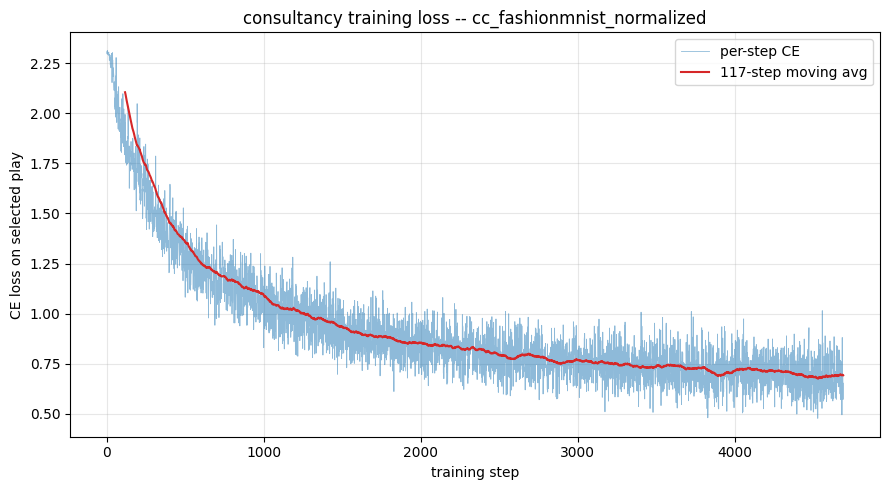

  saved /kaggle/working/claim_conditioned_plots/consultancy_loss_cc_fashionmnist_normalized.png


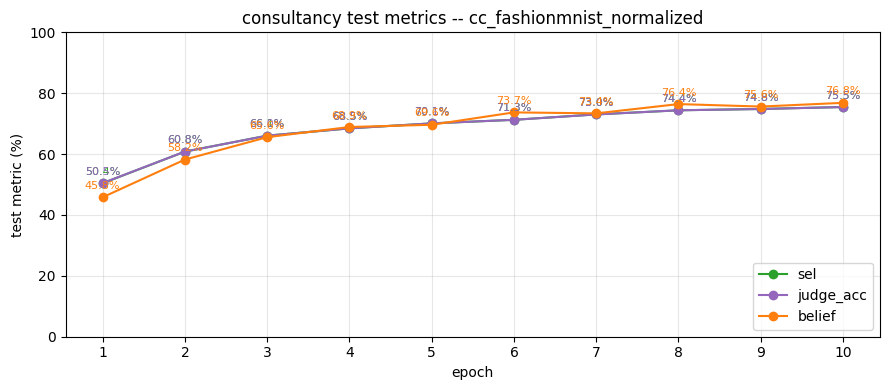

  saved /kaggle/working/claim_conditioned_plots/consultancy_eval_cc_fashionmnist_normalized.png

Final consultancy: sel 75.46%  judge_acc 75.46%  belief 76.84%
  weights at /kaggle/working/claim_conditioned_weights/consultancy_judge_cc_fashionmnist_normalized.pt


In [10]:
DATASET_TAG = CONFIG['dataset']
torch.manual_seed(0)
consultancy_judge = make_consultancy_judge(DATA)
print(f"consultancy judge: {sum(p.numel() for p in consultancy_judge.parameters())} params, "
      f"feat_dim={consultancy_judge.feat_dim}, n_query_digits=1")

cons_weights = os.path.join(CONFIG['weights_dir'], f'consultancy_judge_cc_{DATASET_TAG}.pt')
cons_step_losses, cons_epoch_avg, cons_epoch_metrics = _train_one_judge(
    consultancy_judge, DATA, CONFIG,
    find_best_fn=find_best_consultancy,
    tag='consultancy',
    weights_path=cons_weights)

np.save(os.path.join(CONFIG['data_dir'], f'consultancy_step_loss_cc_{DATASET_TAG}.npy'),
        np.asarray(cons_step_losses, dtype=np.float32))
np.save(os.path.join(CONFIG['data_dir'], f'consultancy_epoch_sel_cc_{DATASET_TAG}.npy'),
        np.asarray([m['sel']       for m in cons_epoch_metrics], dtype=np.float32))
np.save(os.path.join(CONFIG['data_dir'], f'consultancy_epoch_judge_acc_cc_{DATASET_TAG}.npy'),
        np.asarray([m['judge_acc'] for m in cons_epoch_metrics], dtype=np.float32))
np.save(os.path.join(CONFIG['data_dir'], f'consultancy_epoch_belief_cc_{DATASET_TAG}.npy'),
        np.asarray([m['belief']    for m in cons_epoch_metrics], dtype=np.float32))
plot_loss_acc(cons_step_losses, cons_epoch_metrics, f'cc_{DATASET_TAG}', 'consultancy')

print(f"\nFinal consultancy: sel {cons_epoch_metrics[-1]['sel']*100:.2f}%  "
      f"judge_acc {cons_epoch_metrics[-1]['judge_acc']*100:.2f}%  "
      f"belief {cons_epoch_metrics[-1]['belief']*100:.2f}%")
print(f"  weights at {cons_weights}")


## 2) Debate + control judges for each scoring rule

For each rule in `CONFIG['scoring_rules']`, trains four judges
(2-turn debate, 4-turn debate, 2-turn control, 4-turn control).

- `asym`: judge sees $d_A$ only. n_query_digits = 1.
- `sym`, `lastdig`: judge sees both $d_A$ and $d_B$. n_query_digits = 2.



##############################################################################
# Scoring rule: asym  (1/3)  n_query_digits=1
##############################################################################

[asym] debate_2turn: 48138 params, in_channels=2, n_query_digits=1


asym_debate_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 01/10 | avg train loss 1.6450 | sel=51.45% | judge_acc=50.73% | belief=45.05% | elapsed 2.4 min


asym_debate_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 02/10 | avg train loss 1.1974 | sel=59.84% | judge_acc=59.37% | belief=51.61% | elapsed 4.7 min


...

  [asym_debate_2turn] epoch 08/10 | avg train loss 0.7395 | sel=74.18% | judge_acc=74.14% | belief=73.00% | elapsed 19.0 min


asym_debate_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 09/10 | avg train loss 0.7139 | sel=73.56% | judge_acc=73.56% | belief=74.92% | elapsed 21.3 min


asym_debate_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 10/10 | avg train loss 0.7035 | sel=75.36% | judge_acc=75.26% | belief=74.56% | elapsed 23.7 min


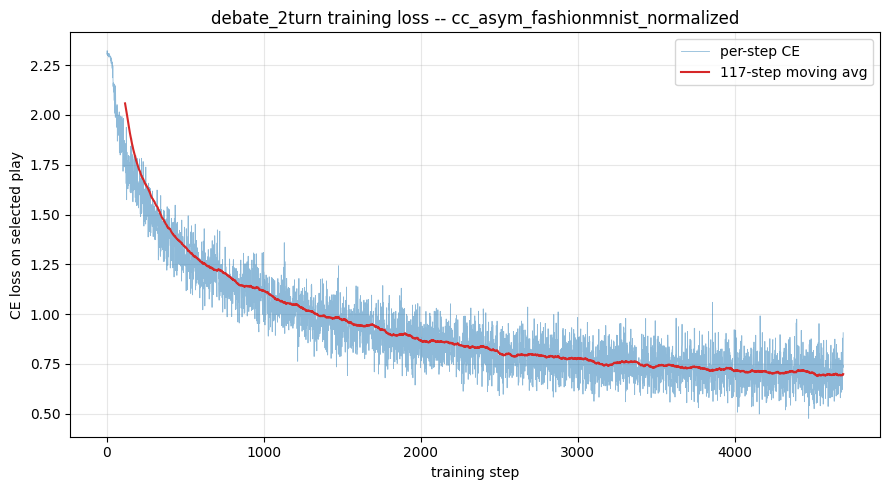

  saved /kaggle/working/claim_conditioned_plots/debate_2turn_loss_cc_asym_fashionmnist_normalized.png


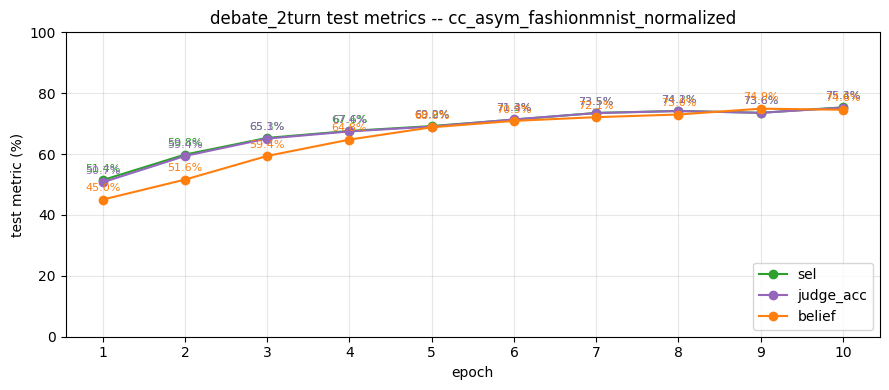

  saved /kaggle/working/claim_conditioned_plots/debate_2turn_eval_cc_asym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/debate_judge_2turn_cc_asym_fashionmnist_normalized.pt

[asym] debate_4turn: 48138 params, in_channels=2, n_query_digits=1


asym_debate_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 01/10 | avg train loss 1.8569 | sel=42.77% | judge_acc=41.84% | belief=37.84% | elapsed 2.3 min


asym_debate_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 02/10 | avg train loss 1.3847 | sel=48.90% | judge_acc=49.47% | belief=45.46% | elapsed 4.6 min


...

  [asym_debate_4turn] epoch 08/10 | avg train loss 0.9863 | sel=63.30% | judge_acc=63.23% | belief=62.42% | elapsed 18.4 min


asym_debate_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 09/10 | avg train loss 0.9660 | sel=63.46% | judge_acc=63.41% | belief=63.09% | elapsed 20.7 min


asym_debate_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 10/10 | avg train loss 0.9464 | sel=65.49% | judge_acc=65.47% | belief=62.70% | elapsed 23.0 min


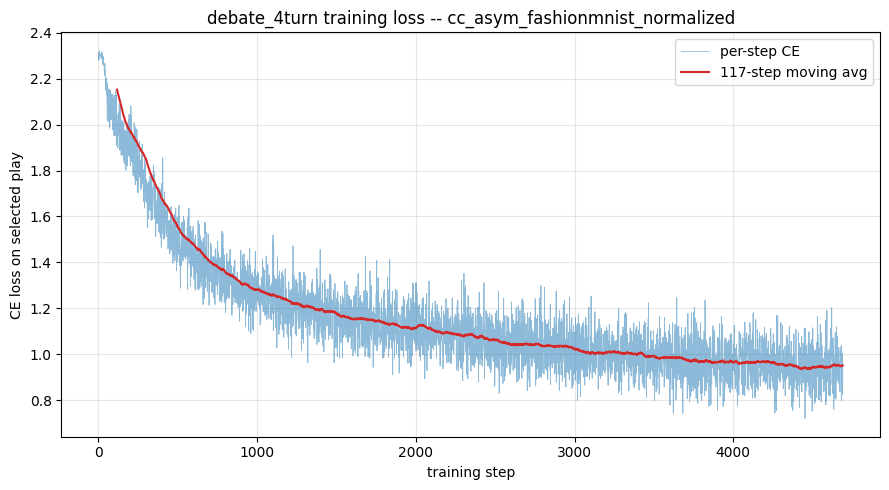

  saved /kaggle/working/claim_conditioned_plots/debate_4turn_loss_cc_asym_fashionmnist_normalized.png


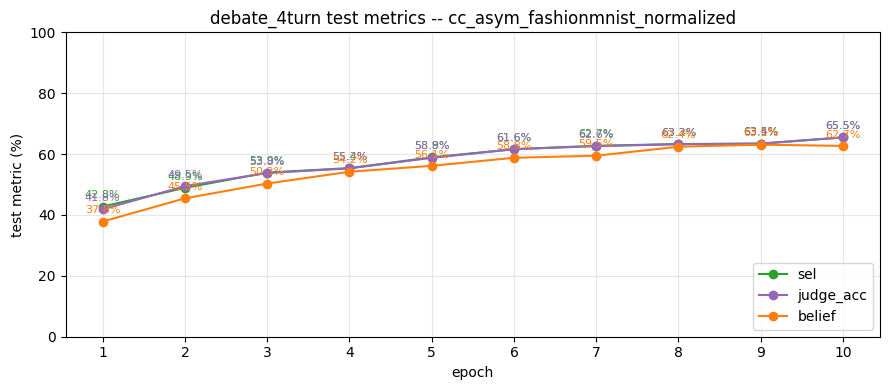

  saved /kaggle/working/claim_conditioned_plots/debate_4turn_eval_cc_asym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/debate_judge_4turn_cc_asym_fashionmnist_normalized.pt

[asym] control_2turn: 48714 params, in_channels=4, n_query_digits=1


asym_control_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 01/10 | avg train loss 1.6882 | sel=50.59% | judge_acc=49.28% | belief=40.04% | elapsed 2.6 min


asym_control_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 02/10 | avg train loss 1.2262 | sel=58.82% | judge_acc=58.44% | belief=53.20% | elapsed 5.2 min


...

  [asym_control_2turn] epoch 08/10 | avg train loss 0.7561 | sel=73.77% | judge_acc=73.77% | belief=73.99% | elapsed 20.6 min


asym_control_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 09/10 | avg train loss 0.7308 | sel=75.05% | judge_acc=75.08% | belief=75.06% | elapsed 23.2 min


asym_control_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 10/10 | avg train loss 0.7120 | sel=75.85% | judge_acc=75.87% | belief=75.13% | elapsed 25.8 min


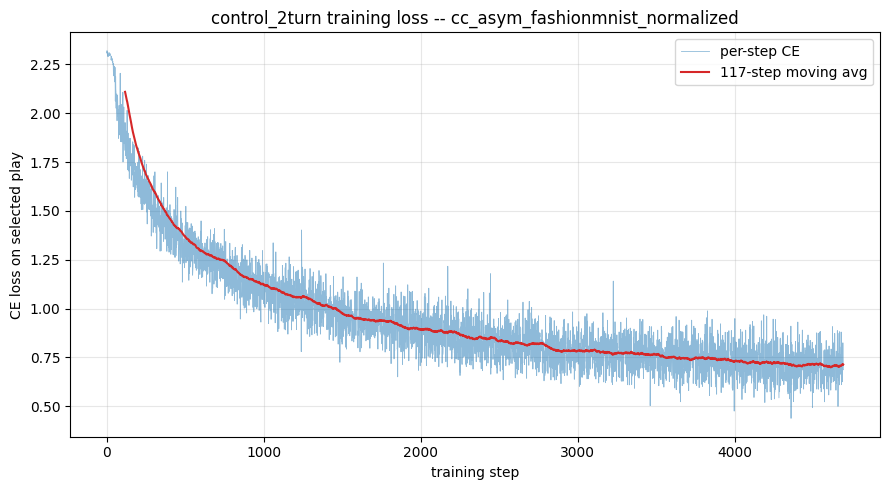

  saved /kaggle/working/claim_conditioned_plots/control_2turn_loss_cc_asym_fashionmnist_normalized.png


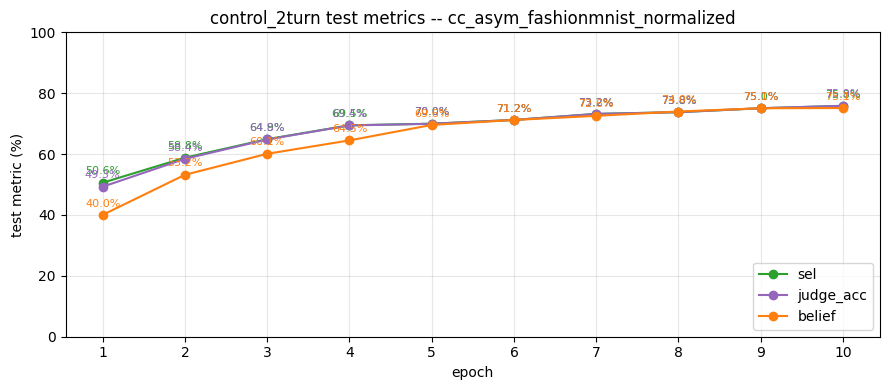

  saved /kaggle/working/claim_conditioned_plots/control_2turn_eval_cc_asym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/control_judge_2turn_cc_asym_fashionmnist_normalized.pt

[asym] control_4turn: 48714 params, in_channels=4, n_query_digits=1


asym_control_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 01/10 | avg train loss 1.8540 | sel=43.15% | judge_acc=42.98% | belief=37.55% | elapsed 2.6 min


asym_control_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 02/10 | avg train loss 1.3636 | sel=51.30% | judge_acc=51.12% | belief=46.80% | elapsed 5.1 min


...

  [asym_control_4turn] epoch 08/10 | avg train loss 0.9673 | sel=65.21% | judge_acc=65.27% | belief=63.77% | elapsed 20.4 min


asym_control_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 09/10 | avg train loss 0.9435 | sel=66.50% | judge_acc=66.54% | belief=65.01% | elapsed 22.9 min


asym_control_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 10/10 | avg train loss 0.9267 | sel=67.83% | judge_acc=67.85% | belief=65.59% | elapsed 25.5 min


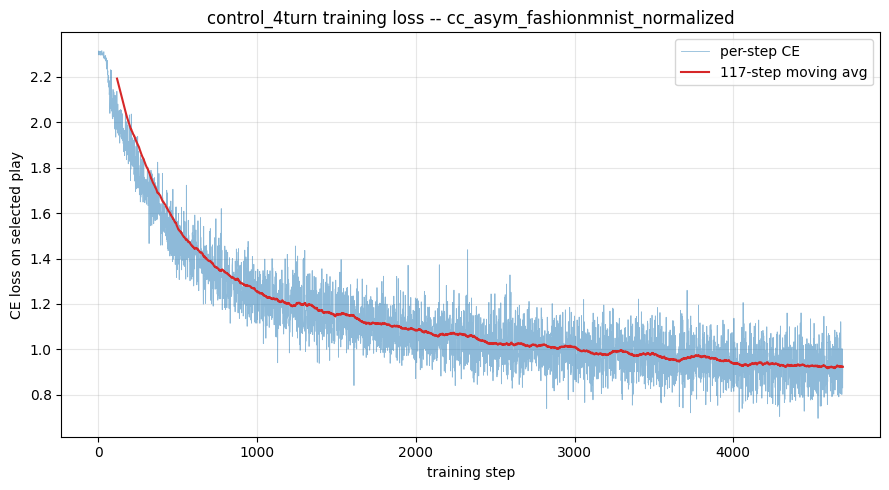

  saved /kaggle/working/claim_conditioned_plots/control_4turn_loss_cc_asym_fashionmnist_normalized.png


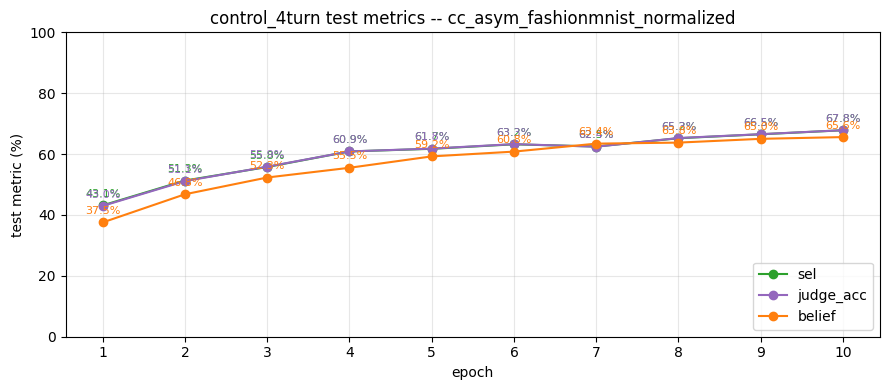

  saved /kaggle/working/claim_conditioned_plots/control_4turn_eval_cc_asym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/control_judge_4turn_cc_asym_fashionmnist_normalized.pt

##############################################################################
# Scoring rule: sym  (2/3)  n_query_digits=2
##############################################################################

[sym] debate_2turn: 48778 params, in_channels=2, n_query_digits=2


sym_debate_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 01/10 | avg train loss 1.6298 | sel=48.14% | judge_acc=47.55% | belief=43.98% | elapsed 4.1 min


sym_debate_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 02/10 | avg train loss 1.2099 | sel=57.48% | judge_acc=57.10% | belief=54.07% | elapsed 8.1 min


...

  [sym_debate_2turn] epoch 08/10 | avg train loss 0.7321 | sel=74.66% | judge_acc=74.65% | belief=74.03% | elapsed 32.5 min


sym_debate_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 09/10 | avg train loss 0.7055 | sel=75.61% | judge_acc=75.50% | belief=74.23% | elapsed 36.6 min


sym_debate_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 10/10 | avg train loss 0.6881 | sel=76.23% | judge_acc=76.10% | belief=74.53% | elapsed 40.7 min


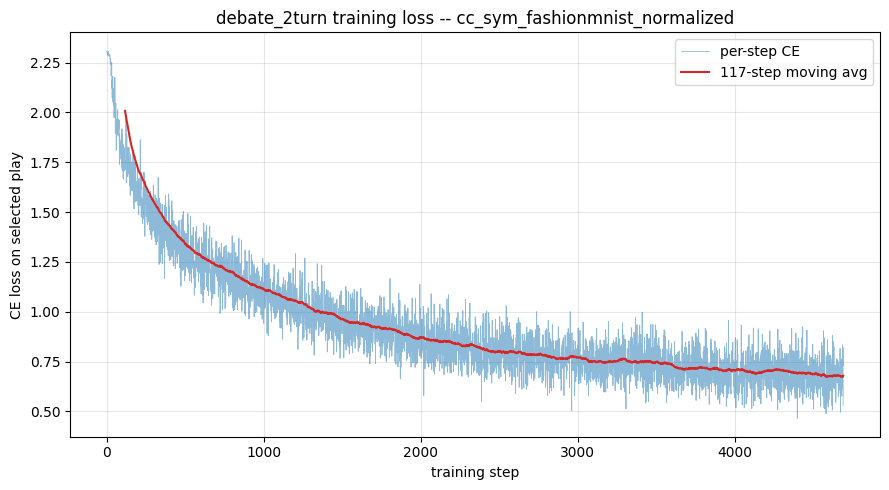

  saved /kaggle/working/claim_conditioned_plots/debate_2turn_loss_cc_sym_fashionmnist_normalized.png


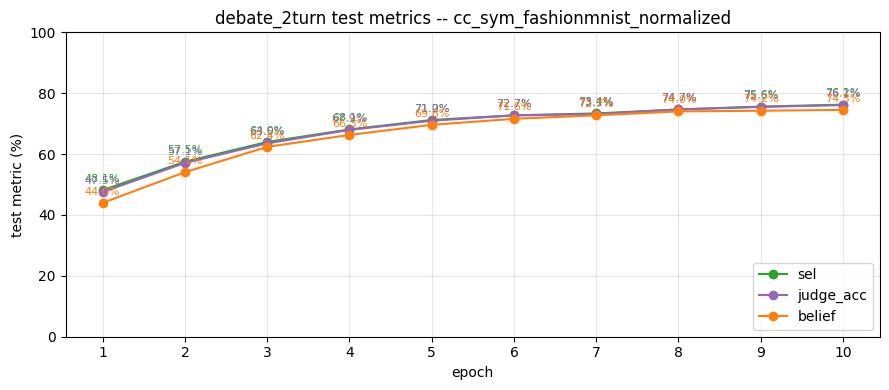

  saved /kaggle/working/claim_conditioned_plots/debate_2turn_eval_cc_sym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/debate_judge_2turn_cc_sym_fashionmnist_normalized.pt

[sym] debate_4turn: 48778 params, in_channels=2, n_query_digits=2


sym_debate_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 01/10 | avg train loss 1.8379 | sel=44.67% | judge_acc=43.88% | belief=37.36% | elapsed 4.0 min


sym_debate_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 02/10 | avg train loss 1.3523 | sel=52.48% | judge_acc=52.19% | belief=47.11% | elapsed 8.0 min


...

  [sym_debate_4turn] epoch 08/10 | avg train loss 0.9242 | sel=66.68% | judge_acc=66.56% | belief=66.55% | elapsed 32.0 min


sym_debate_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 09/10 | avg train loss 0.9016 | sel=68.27% | judge_acc=68.17% | belief=66.02% | elapsed 36.0 min


sym_debate_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 10/10 | avg train loss 0.8808 | sel=67.50% | judge_acc=67.54% | belief=68.73% | elapsed 40.0 min


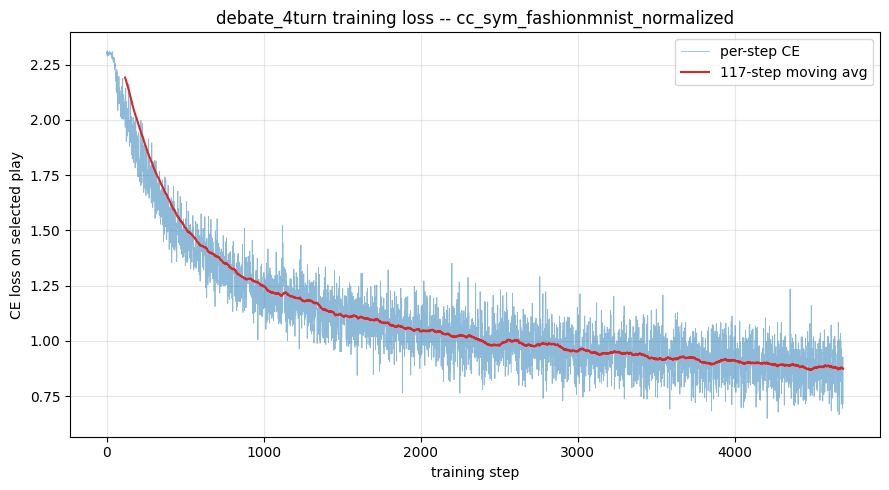

  saved /kaggle/working/claim_conditioned_plots/debate_4turn_loss_cc_sym_fashionmnist_normalized.png


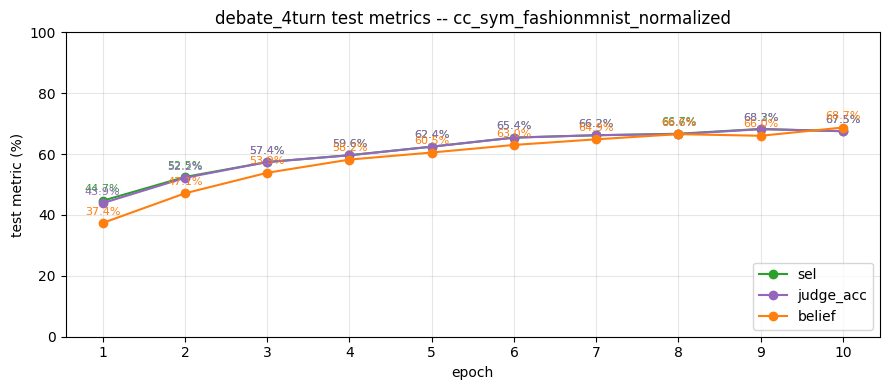

  saved /kaggle/working/claim_conditioned_plots/debate_4turn_eval_cc_sym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/debate_judge_4turn_cc_sym_fashionmnist_normalized.pt

[sym] control_2turn: 49354 params, in_channels=4, n_query_digits=2


sym_control_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 01/10 | avg train loss 1.7213 | sel=46.34% | judge_acc=45.64% | belief=41.69% | elapsed 4.3 min


sym_control_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 02/10 | avg train loss 1.2540 | sel=56.79% | judge_acc=56.23% | belief=50.68% | elapsed 8.5 min


...

  [sym_control_2turn] epoch 08/10 | avg train loss 0.7820 | sel=72.99% | judge_acc=72.98% | belief=72.86% | elapsed 34.1 min


sym_control_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 09/10 | avg train loss 0.7639 | sel=73.41% | judge_acc=73.49% | belief=73.05% | elapsed 38.3 min


sym_control_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 10/10 | avg train loss 0.7457 | sel=74.29% | judge_acc=74.30% | belief=74.41% | elapsed 42.6 min


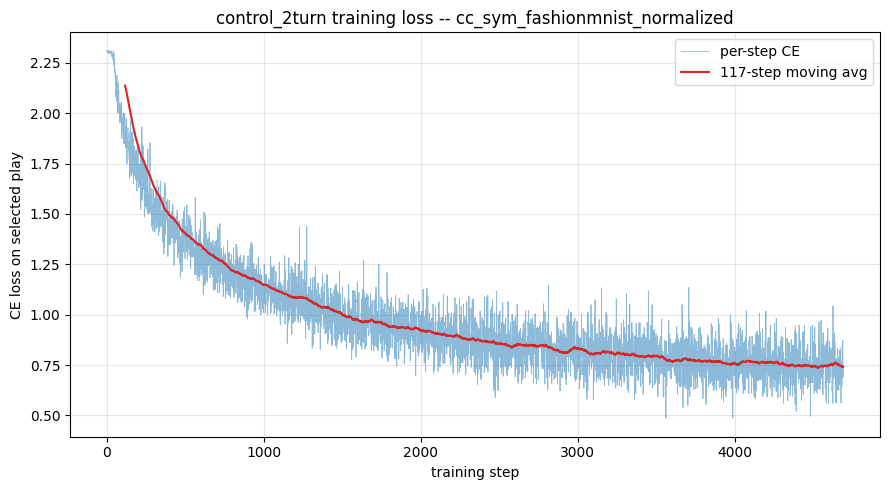

  saved /kaggle/working/claim_conditioned_plots/control_2turn_loss_cc_sym_fashionmnist_normalized.png


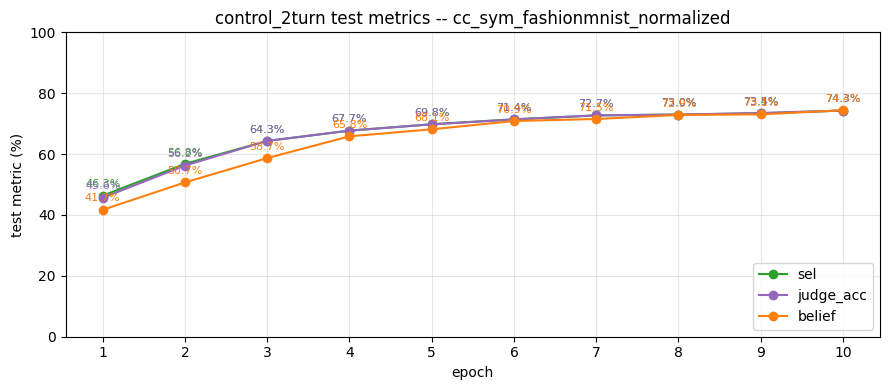

  saved /kaggle/working/claim_conditioned_plots/control_2turn_eval_cc_sym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/control_judge_2turn_cc_sym_fashionmnist_normalized.pt

[sym] control_4turn: 49354 params, in_channels=4, n_query_digits=2


sym_control_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 01/10 | avg train loss 1.8595 | sel=44.97% | judge_acc=44.34% | belief=34.37% | elapsed 4.2 min


sym_control_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 02/10 | avg train loss 1.3998 | sel=49.53% | judge_acc=49.77% | belief=45.54% | elapsed 8.5 min


...

  [sym_control_4turn] epoch 08/10 | avg train loss 1.0115 | sel=64.19% | judge_acc=64.21% | belief=62.23% | elapsed 34.0 min


sym_control_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 09/10 | avg train loss 0.9835 | sel=64.58% | judge_acc=64.60% | belief=61.92% | elapsed 38.3 min


sym_control_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 10/10 | avg train loss 0.9649 | sel=66.01% | judge_acc=65.96% | belief=63.49% | elapsed 42.5 min


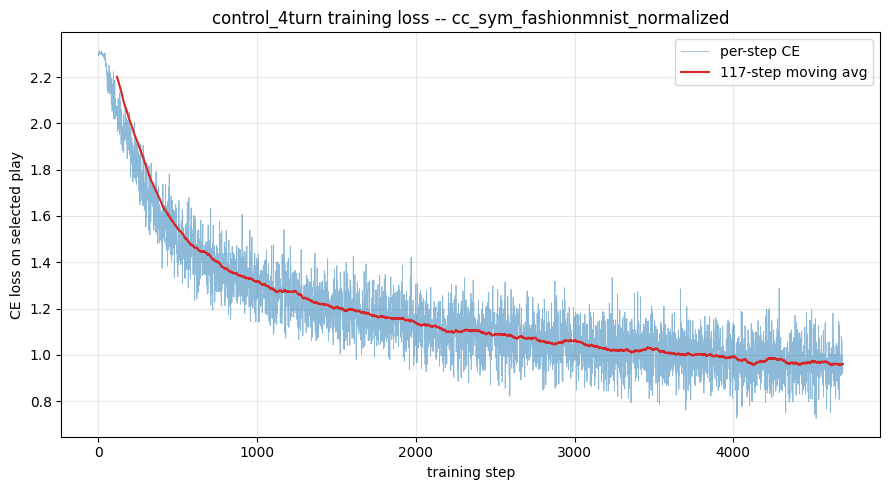

  saved /kaggle/working/claim_conditioned_plots/control_4turn_loss_cc_sym_fashionmnist_normalized.png


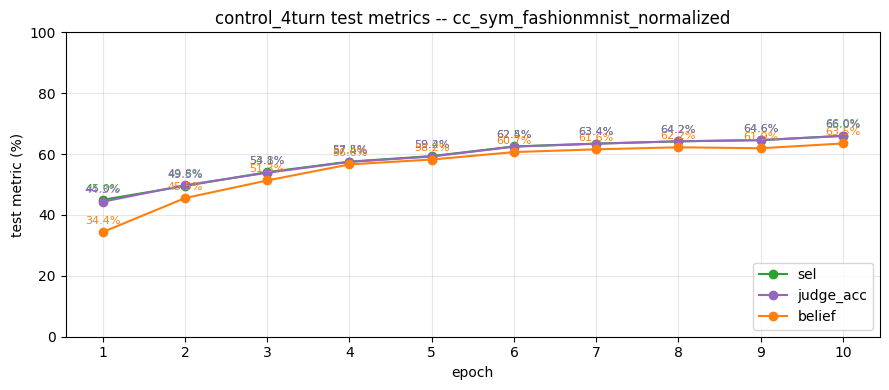

  saved /kaggle/working/claim_conditioned_plots/control_4turn_eval_cc_sym_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/control_judge_4turn_cc_sym_fashionmnist_normalized.pt

##############################################################################
# Scoring rule: lastdig  (3/3)  n_query_digits=2
##############################################################################

[lastdig] debate_2turn: 48778 params, in_channels=2, n_query_digits=2


lastdig_debate_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 01/10 | avg train loss 1.6356 | sel=46.66% | judge_acc=46.59% | belief=48.59% | elapsed 4.1 min


lastdig_debate_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 02/10 | avg train loss 1.2122 | sel=58.08% | judge_acc=57.10% | belief=52.46% | elapsed 8.1 min


...

  [lastdig_debate_2turn] epoch 08/10 | avg train loss 0.7460 | sel=74.57% | judge_acc=74.55% | belief=74.00% | elapsed 32.5 min


lastdig_debate_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 09/10 | avg train loss 0.7218 | sel=74.05% | judge_acc=74.05% | belief=74.25% | elapsed 36.6 min


lastdig_debate_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 10/10 | avg train loss 0.7119 | sel=75.50% | judge_acc=75.38% | belief=75.17% | elapsed 40.7 min


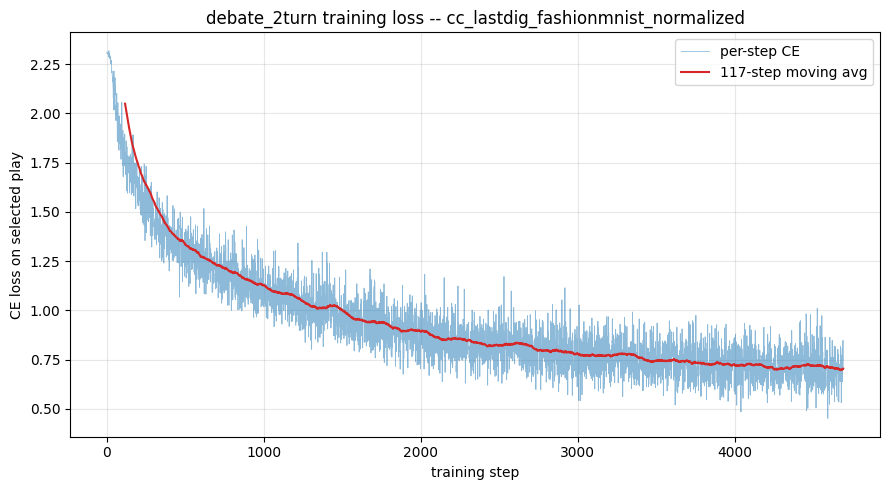

  saved /kaggle/working/claim_conditioned_plots/debate_2turn_loss_cc_lastdig_fashionmnist_normalized.png


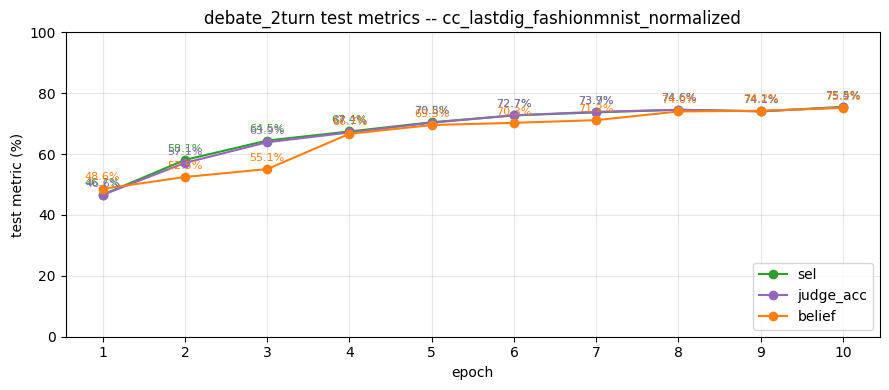

  saved /kaggle/working/claim_conditioned_plots/debate_2turn_eval_cc_lastdig_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/debate_judge_2turn_cc_lastdig_fashionmnist_normalized.pt

[lastdig] debate_4turn: 48778 params, in_channels=2, n_query_digits=2


lastdig_debate_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 01/10 | avg train loss 1.8259 | sel=43.85% | judge_acc=42.77% | belief=34.98% | elapsed 4.0 min


lastdig_debate_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 02/10 | avg train loss 1.3814 | sel=46.52% | judge_acc=47.31% | belief=44.72% | elapsed 8.0 min


...

  [lastdig_debate_4turn] epoch 08/10 | avg train loss 0.9751 | sel=63.78% | judge_acc=63.80% | belief=63.37% | elapsed 32.0 min


lastdig_debate_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 09/10 | avg train loss 0.9484 | sel=65.70% | judge_acc=65.64% | belief=62.40% | elapsed 36.0 min


lastdig_debate_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 10/10 | avg train loss 0.9225 | sel=66.75% | judge_acc=66.79% | belief=65.63% | elapsed 40.0 min


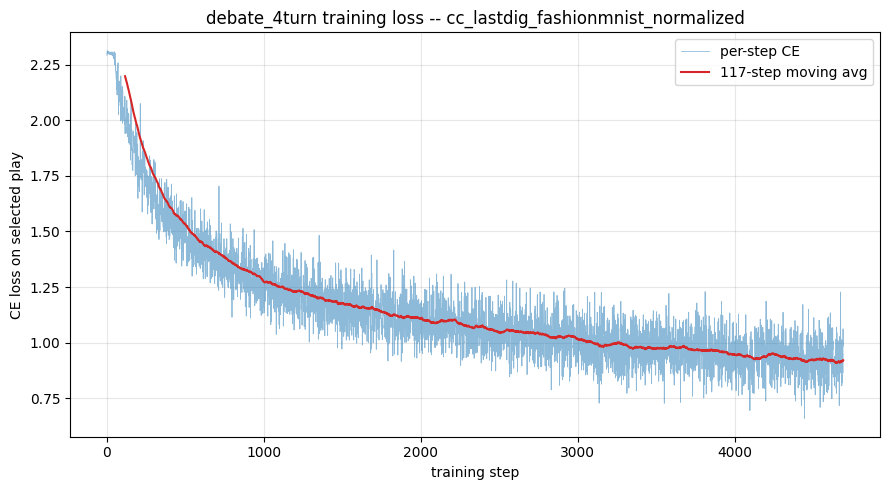

  saved /kaggle/working/claim_conditioned_plots/debate_4turn_loss_cc_lastdig_fashionmnist_normalized.png


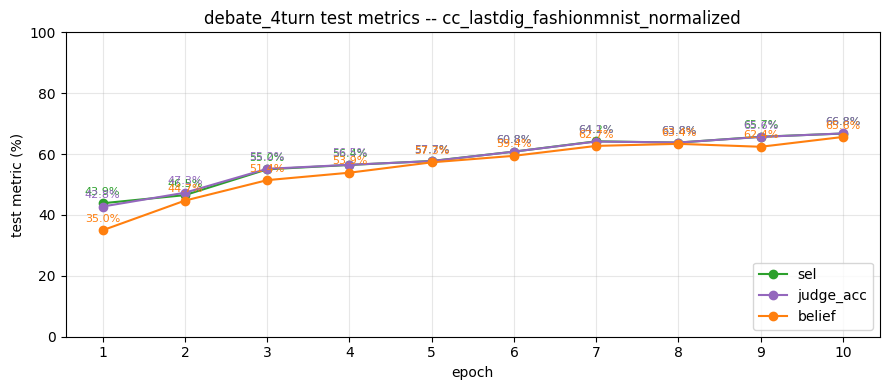

  saved /kaggle/working/claim_conditioned_plots/debate_4turn_eval_cc_lastdig_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/debate_judge_4turn_cc_lastdig_fashionmnist_normalized.pt

[lastdig] control_2turn: 49354 params, in_channels=4, n_query_digits=2


lastdig_control_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 01/10 | avg train loss 1.6640 | sel=50.57% | judge_acc=48.70% | belief=38.03% | elapsed 4.3 min


lastdig_control_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 02/10 | avg train loss 1.2324 | sel=57.35% | judge_acc=57.12% | belief=53.29% | elapsed 8.5 min


...

  [lastdig_control_2turn] epoch 08/10 | avg train loss 0.7393 | sel=73.78% | judge_acc=73.85% | belief=73.09% | elapsed 34.1 min


lastdig_control_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 09/10 | avg train loss 0.7180 | sel=75.14% | judge_acc=75.12% | belief=75.18% | elapsed 38.3 min


lastdig_control_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 10/10 | avg train loss 0.7065 | sel=75.34% | judge_acc=75.36% | belief=75.09% | elapsed 42.6 min


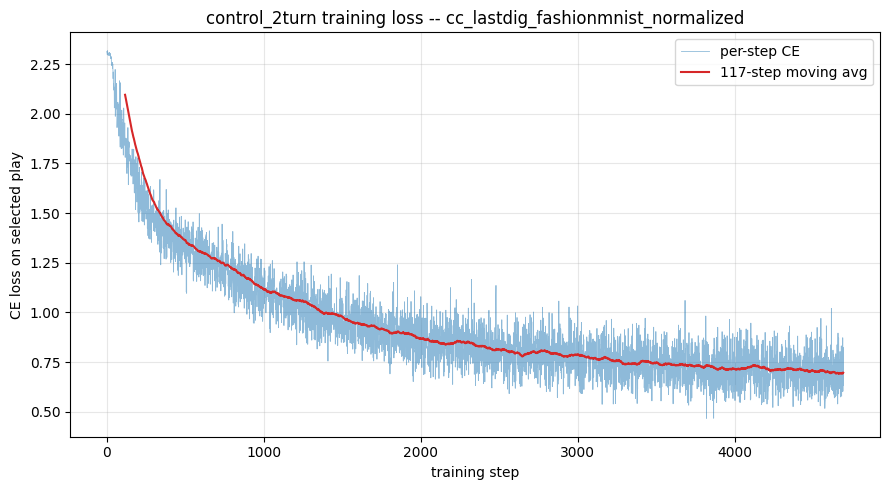

  saved /kaggle/working/claim_conditioned_plots/control_2turn_loss_cc_lastdig_fashionmnist_normalized.png


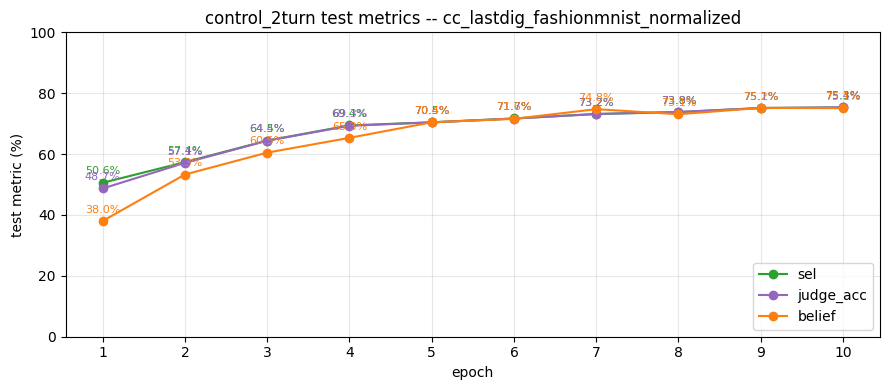

  saved /kaggle/working/claim_conditioned_plots/control_2turn_eval_cc_lastdig_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/control_judge_2turn_cc_lastdig_fashionmnist_normalized.pt

[lastdig] control_4turn: 49354 params, in_channels=4, n_query_digits=2


lastdig_control_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 01/10 | avg train loss 1.8452 | sel=43.30% | judge_acc=43.84% | belief=39.06% | elapsed 4.3 min


lastdig_control_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 02/10 | avg train loss 1.3700 | sel=47.94% | judge_acc=48.98% | belief=48.24% | elapsed 8.5 min


...

  [lastdig_control_4turn] epoch 08/10 | avg train loss 0.9837 | sel=65.35% | judge_acc=65.28% | belief=62.90% | elapsed 34.0 min


lastdig_control_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 09/10 | avg train loss 0.9638 | sel=65.68% | judge_acc=65.74% | belief=64.25% | elapsed 38.3 min


lastdig_control_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 10/10 | avg train loss 0.9427 | sel=66.03% | judge_acc=65.98% | belief=65.25% | elapsed 42.5 min


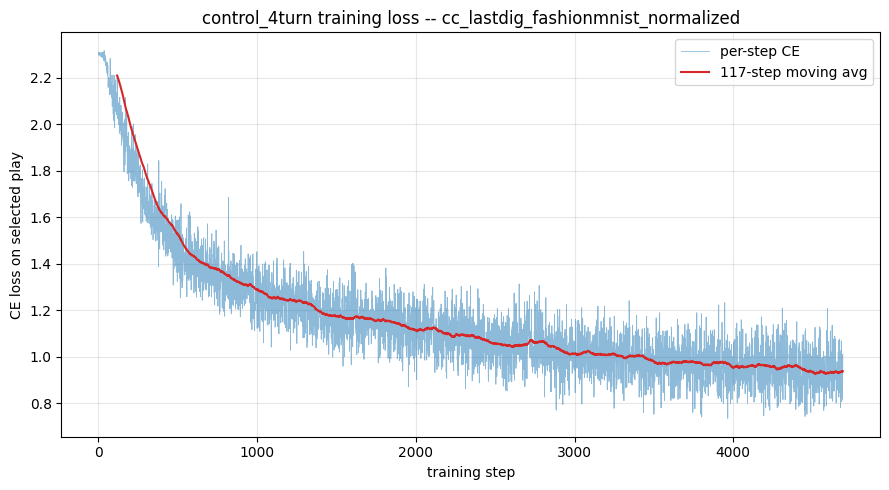

  saved /kaggle/working/claim_conditioned_plots/control_4turn_loss_cc_lastdig_fashionmnist_normalized.png


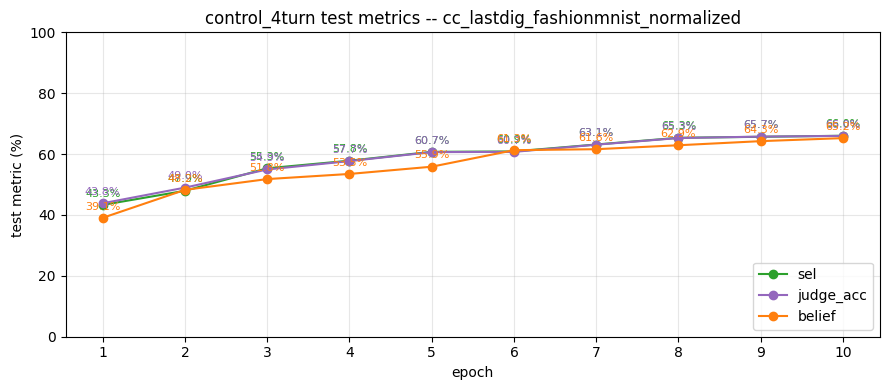

  saved /kaggle/working/claim_conditioned_plots/control_4turn_eval_cc_lastdig_fashionmnist_normalized.png
  weights at /kaggle/working/claim_conditioned_weights/control_judge_4turn_cc_lastdig_fashionmnist_normalized.pt


In [11]:
from functools import partial

ALL_RESULTS = {'consultancy': {'final': cons_epoch_metrics[-1]}}

for rule_idx, rule in enumerate(CONFIG['scoring_rules']):
    info = SCORING_RULES[rule]
    reduce_2, reduce_4, nqd = info['reduce_2turn'], info['reduce_4turn'], info['n_query_digits']

    fb_2turn         = partial(find_best_2turn,         reduce_fn=reduce_2, n_query_digits=nqd)
    fb_4turn         = partial(find_best_4turn,         reduce_fn=reduce_4, n_query_digits=nqd)
    fb_2turn_control = partial(find_best_2turn_control, reduce_fn=reduce_2, n_query_digits=nqd)
    fb_4turn_control = partial(find_best_4turn_control, reduce_fn=reduce_4, n_query_digits=nqd)

    rule_tag = f'cc_{rule}_{DATASET_TAG}'
    ALL_RESULTS[rule] = {}

    print("\n" + "#" * 78)
    print(f"# Scoring rule: {rule}  ({rule_idx+1}/{len(CONFIG['scoring_rules'])})  "
          f"n_query_digits={nqd}")
    print("#" * 78)

    judge_specs = [
        ('debate_2turn',  make_debate_judge,  fb_2turn,         2 * DATA['in_channels']),
        ('debate_4turn',  make_debate_judge,  fb_4turn,         2 * DATA['in_channels']),
        ('control_2turn', make_control_judge, fb_2turn_control, 4 * DATA['in_channels']),
        ('control_4turn', make_control_judge, fb_4turn_control, 4 * DATA['in_channels']),
    ]
    for kind_idx, (kind, make_fn, find_best_fn, in_ch) in enumerate(judge_specs):
        torch.manual_seed(1 + 4 * rule_idx + kind_idx)
        judge = make_fn(DATA, n_query_digits=nqd)
        print(f"\n[{rule}] {kind}: {sum(p.numel() for p in judge.parameters())} params, "
              f"in_channels={in_ch}, n_query_digits={nqd}")
        weights_path = os.path.join(CONFIG['weights_dir'],
                                    f'{kind.split("_")[0]}_judge_{kind.split("_")[1]}_{rule_tag}.pt')
        step_losses, _, metrics = _train_one_judge(
            judge, DATA, CONFIG,
            find_best_fn=find_best_fn, tag=f'{rule}_{kind}',
            weights_path=weights_path)
        np.save(os.path.join(CONFIG['data_dir'], f'{kind}_step_loss_{rule_tag}.npy'),
                np.asarray(step_losses, dtype=np.float32))
        np.save(os.path.join(CONFIG['data_dir'], f'{kind}_epoch_sel_{rule_tag}.npy'),
                np.asarray([m['sel']       for m in metrics], dtype=np.float32))
        np.save(os.path.join(CONFIG['data_dir'], f'{kind}_epoch_judge_acc_{rule_tag}.npy'),
                np.asarray([m['judge_acc'] for m in metrics], dtype=np.float32))
        np.save(os.path.join(CONFIG['data_dir'], f'{kind}_epoch_belief_{rule_tag}.npy'),
                np.asarray([m['belief']    for m in metrics], dtype=np.float32))
        plot_loss_acc(step_losses, metrics, rule_tag, kind)
        ALL_RESULTS[rule][kind] = metrics[-1]
        print(f"  weights at {weights_path}")
        del judge; gc.collect()
        if CONFIG['device'] == 'cuda':
            torch.cuda.empty_cache()


## 3) Final summary table

In [12]:
print("=" * 100)
print(f"CLAIM-CONDITIONED CLASSIFIER JUDGE SUMMARY for dataset '{DATASET_TAG}'")
print("=" * 100)
print(f"  {'rule':<10s}  {'judge':<16s}  {'sel acc':>9s}  {'judge acc':>10s}  {'belief':>9s}")
print(f"  {'-'*10}  {'-'*16}  {'-'*9}  {'-'*10}  {'-'*9}")
m = ALL_RESULTS['consultancy']['final']
print(f"  {'--':<10s}  {'consultancy':<16s}  "
      f"{m['sel']*100:>8.2f}%  {m['judge_acc']*100:>9.2f}%  {m['belief']*100:>8.2f}%")
for rule in CONFIG['scoring_rules']:
    for kind in ('debate_2turn', 'debate_4turn', 'control_2turn', 'control_4turn'):
        m = ALL_RESULTS[rule][kind]
        print(f"  {rule:<10s}  {kind:<16s}  "
              f"{m['sel']*100:>8.2f}%  {m['judge_acc']*100:>9.2f}%  {m['belief']*100:>8.2f}%")


CLAIM-CONDITIONED CLASSIFIER JUDGE SUMMARY for dataset 'fashionmnist_normalized'
  rule        judge               sel acc   judge acc     belief
  ----------  ----------------  ---------  ----------  ---------
  --          consultancy          75.46%      75.46%     76.84%
  asym        debate_2turn         75.36%      75.26%     74.56%
  asym        debate_4turn         65.49%      65.47%     62.70%
  asym        control_2turn        75.85%      75.87%     75.13%
  asym        control_4turn        67.83%      67.85%     65.59%
  sym         debate_2turn         76.23%      76.10%     74.53%
  sym         debate_4turn         67.50%      67.54%     68.73%
  sym         control_2turn        74.29%      74.30%     74.41%
  sym         control_4turn        66.01%      65.96%     63.49%
  lastdig     debate_2turn         75.50%      75.38%     75.17%
  lastdig     debate_4turn         66.75%      66.79%     65.63%
  lastdig     control_2turn        75.34%      75.36%     75.09%
  lastdig